# Model Recommendation — Maser Survey

> **Synthetic data analysis.** Real galaxy feature distributions with invented labels,
> so performance is measured against known ground truth.  
> Signal strength = 3.0 &nbsp;·&nbsp; N = 8 seeds &nbsp;·&nbsp; 5-fold CV × 4 repeats &nbsp;·&nbsp; No `class_weight`  
> **`ceiling=0.4`** — p_true capped at 0.4 to reflect the inclination lottery (beaming geometry means even a perfect candidate rarely exceeds ~40% detection probability). Updated July 2026.

---

## Metrics

| Metric | What it measures | Notes |
|---|---|---|
| **AUC** | Did the model learn the boundary shape? | 0.5 = random, 1.0 = perfect |
| **Brier** | Are the probability scores accurate? | MSE between predicted probability and 0/1 outcome. Lower = better |
| **Brier pt** | MSE against the simulator's exact probabilities | Removes 0/1 label noise — a cleaner calibration check. Lower = better |
| **P@10 / fold** | Masers found in a top-50 campaign | Top-10 per fold × 5 folds = 50 galaxies observed |

---

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve
warnings.filterwarnings("ignore")

In [2]:
# Adjust these paths to match your directory structure
MASERS_DIR = Path(".")          # directory containing this notebook
DATA_DIR   = MASERS_DIR / "2"  # directory containing maser_data.py and raw data

sys.path.insert(0, str(MASERS_DIR))
sys.path.insert(0, str(DATA_DIR))

import maser_data
maser_data.DATA_RAW = DATA_DIR
import synth_data as sd

SCENARIOS = ["linear", "wedge", "box", "interaction", "blob"]
PLANE     = "xray"
FEAT      = sd.PLANES["xray"]["columns"]
TGT       = sd.PLANES["xray"]["target"]
STRENGTH  = 3.0
N_SEEDS   = 8
N_SPLITS  = 5
N_REPEATS = 4

In [3]:
def make_lr():
    return Pipeline([("sc",  StandardScaler()),
                     ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=42))])

def qlr_builder(C):
    def build():
        return Pipeline([("sc",   StandardScaler()),
                         ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                         ("clf",  LogisticRegression(C=C, max_iter=2000, random_state=42))])
    build.__name__ = f"QLR C={C}"
    return build

def rf_builder(msl, depth=3, max_features=2):
    def build():
        return RandomForestClassifier(n_estimators=200, max_features=max_features,
                                      min_samples_leaf=msl, max_depth=depth,
                                      random_state=42, n_jobs=-1)
    build.__name__ = f"RF msl={msl} d={depth}"
    return build

def gbt_builder(depth, n_iter=150, lr=0.1):
    def build():
        return HistGradientBoostingClassifier(max_iter=n_iter, max_depth=depth,
                                              learning_rate=lr, random_state=42)
    build.__name__ = f"GBT d={depth}"
    return build

HP_CANDIDATES = {
    "LR":            make_lr,
    "QLR C=1.0":     qlr_builder(1.0),
    "QLR C=0.1":     qlr_builder(0.1),
    "RF msl=5 d=3":  rf_builder(5,  depth=3, max_features=2),
    "RF msl=10 d=3": rf_builder(10, depth=3, max_features=2),
    "RF msl=20":     rf_builder(20, depth=None, max_features=2),
    "GBT d=2":       gbt_builder(2),
    "GBT d=3":       gbt_builder(3),
}

In [4]:
def fold_metrics(build_fn, df, feat=FEAT, tgt=TGT,
                 n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=0):
    X  = df[feat].values
    y  = df[tgt].values
    pt = df["p_true"].values
    null_brier = y.mean() * (1 - y.mean())

    rocs, b01s, bsss, bpts, p10s = [], [], [], [], []
    y_pool, p_pool = [], []
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for tr, te in skf.split(X, y):
            if y[tr].sum() < 3 or y[te].sum() < 1:
                continue
            m = build_fn().fit(X[tr], y[tr])
            p = m.predict_proba(X[te])[:, 1]
            yte, pte = y[te], pt[te]
            if y[te].sum() >= 2:
                rocs.append(roc_auc_score(yte, p))
            b01 = np.mean((p - yte) ** 2)
            b01s.append(b01)
            bsss.append(1 - b01 / null_brier if null_brier > 0 else np.nan)
            bpts.append(np.mean((p - pte) ** 2))
            k    = min(10, len(yte))
            topk = np.argsort(p)[::-1][:k]
            p10s.append(yte[topk].mean())
            y_pool.append(yte)
            p_pool.append(p)

    y_all = np.concatenate(y_pool)
    p_all = np.concatenate(p_pool)
    top50 = np.argsort(p_all)[::-1][:min(50, len(y_all))]

    return dict(
        roc            = np.nanmean(rocs),
        brier          = np.mean(b01s),
        bss            = np.nanmean(bsss),
        brier_pt       = np.mean(bpts),
        p10            = np.mean(p10s),
        p10_std        = np.std(p10s),
        prec50         = y_all[top50].mean(),
        promised_at_n  = float(p_all[top50].sum()),
        delivered_at_n = float(y_all[top50].sum()),
    )

def oof_predict(build_fn, df, feat=FEAT, tgt=TGT, seed=42):
    X, y = df[feat].values, df[tgt].values
    proba = np.zeros(len(y))
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for tr, te in skf.split(X, y):
        m = build_fn().fit(X[tr], y[tr])
        proba[te] = m.predict_proba(X[te])[:, 1]
    return proba, y

---
## Step 1 — Hyperparameter Selection

P@10/fold averaged across the four non-linear scenarios (wedge, box, interaction, blob).  
Linear excluded — it is logistic regression's home turf and not representative of the harder cases.  
Winners per model family carry forward to Step 2.

> **Note:** this cell takes ~10–15 minutes to run (8 seeds × 4 scenarios × 8 candidates).  
> **ceiling=0.4 results (re-run to refresh):** QLR C=1.0 = 0.306 · RF msl=20 = 0.298 · GBT d=2 = 0.257 · LR = 0.194

In [5]:
NON_LINEAR = ["wedge", "box", "interaction", "blob"]
hp_scores = {}
for mname, mfn in HP_CANDIDATES.items():
    p10_vals = []
    for sc in NON_LINEAR:
        for seed in range(N_SEEDS):
            df_sc = sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=seed)
            ev = fold_metrics(mfn, df_sc, seed=seed * 13)
            p10_vals.append(ev["p10"])
    hp_scores[mname] = np.mean(p10_vals)
    print(f"  {mname:14s}  mean P@10 = {hp_scores[mname]:.3f}")

best_rf  = max((n for n in HP_CANDIDATES if n.startswith("RF")),  key=lambda n: hp_scores[n])
best_gbt = max((n for n in HP_CANDIDATES if n.startswith("GBT")), key=lambda n: hp_scores[n])
best_qlr = max((n for n in HP_CANDIDATES if n.startswith("QLR")), key=lambda n: hp_scores[n])
print(f"\n  \u2192 Best RF:  {best_rf}  (P@10 = {hp_scores[best_rf]:.3f})")
print(f"  \u2192 Best GBT: {best_gbt}  (P@10 = {hp_scores[best_gbt]:.3f})")
print(f"  \u2192 Best QLR: {best_qlr}  (P@10 = {hp_scores[best_qlr]:.3f})")

best_rf_fn  = HP_CANDIDATES[best_rf]
best_gbt_fn = HP_CANDIDATES[best_gbt]
best_qlr_fn = HP_CANDIDATES[best_qlr]

def make_ensemble():
    rf  = best_rf_fn()
    gbt = best_gbt_fn()
    class _E:
        def fit(self, X, y):
            rf.fit(X, y); gbt.fit(X, y); return self
        def predict_proba(self, X):
            p = (rf.predict_proba(X)[:, 1] + gbt.predict_proba(X)[:, 1]) / 2
            return np.column_stack([1 - p, p])
    return _E()

FINAL_MODELS = {
    "LR":       make_lr,
    best_qlr:   best_qlr_fn,
    best_rf:    best_rf_fn,
    best_gbt:   best_gbt_fn,
    "Ensemble": make_ensemble,
}
MODEL_CLR = {
    "LR":       "#3498DB",
    best_qlr:   "#F39C12",
    best_rf:    "#E74C3C",
    best_gbt:   "#2ECC71",
    "Ensemble": "#9B59B6",
}

  LR              mean P@10 = 0.194


  QLR C=1.0       mean P@10 = 0.306


  QLR C=0.1       mean P@10 = 0.305


  RF msl=5 d=3    mean P@10 = 0.285


  RF msl=10 d=3   mean P@10 = 0.289


  RF msl=20       mean P@10 = 0.298


  GBT d=2         mean P@10 = 0.257


  GBT d=3         mean P@10 = 0.239

  → Best RF:  RF msl=20  (P@10 = 0.298)
  → Best GBT: GBT d=2  (P@10 = 0.257)
  → Best QLR: QLR C=1.0  (P@10 = 0.306)


In [6]:
settings_map = {
    "LR":            "C=1.0, StandardScaler",
    "QLR C=1.0":     "degree=2 polynomial features, C=1.0",
    "QLR C=0.1":     "degree=2 polynomial features, C=0.1",
    "RF msl=5 d=3":  "min_samples_leaf=5,  max_depth=3, max_features=2",
    "RF msl=10 d=3": "min_samples_leaf=10, max_depth=3, max_features=2",
    "RF msl=20":     "min_samples_leaf=20, max_depth=None, max_features=2",
    "GBT d=2":       "max_depth=2, max_iter=150, lr=0.1",
    "GBT d=3":       "max_depth=3, max_iter=150, lr=0.1",
}
hp_df = (
    pd.DataFrame([
        {"Model": k, "Settings": settings_map[k], "Mean P@10 (non-linear)": v}
        for k, v in hp_scores.items()
    ])
    .sort_values("Mean P@10 (non-linear)", ascending=False)
    .reset_index(drop=True)
)
(hp_df.style
      .format({"Mean P@10 (non-linear)": "{:.3f}"})
      .highlight_max(subset=["Mean P@10 (non-linear)"], color="#fffacd")
      .hide(axis="index"))

Model,Settings,Mean P@10 (non-linear)
QLR C=1.0,"degree=2 polynomial features, C=1.0",0.306
QLR C=0.1,"degree=2 polynomial features, C=0.1",0.305
RF msl=20,"min_samples_leaf=20, max_depth=None, max_features=2",0.298
RF msl=10 d=3,"min_samples_leaf=10, max_depth=3, max_features=2",0.289
RF msl=5 d=3,"min_samples_leaf=5, max_depth=3, max_features=2",0.285
GBT d=2,"max_depth=2, max_iter=150, lr=0.1",0.257
GBT d=3,"max_depth=3, max_iter=150, lr=0.1",0.239
LR,"C=1.0, StandardScaler",0.194


---
## Step 2 — Full Evaluation

All five scenarios, all final models, 8 seeds each.  
> **Note:** this cell takes ~15–20 minutes to run (8 seeds × 5 scenarios × 5 models). Also computes `promised_at_n` and `delivered_at_n` for calibration plots.

In [7]:
rows = []
pvd_data = []  # per-seed promised vs delivered records for calibration plots

for sc in SCENARIOS:
    for mname, mfn in FINAL_MODELS.items():
        agg = {k: [] for k in ["roc", "brier", "bss", "brier_pt", "p10", "p10_std",
                                "prec50", "promised_at_n", "delivered_at_n"]}
        for seed in range(N_SEEDS):
            df_sc = sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=seed)
            ev = fold_metrics(mfn, df_sc, seed=seed * 13)
            for k in agg:
                agg[k].append(ev[k])
            pvd_data.append({"scenario": sc, "model": mname, "seed": seed,
                             "promised": ev["promised_at_n"],
                             "delivered": ev["delivered_at_n"]})
        row = dict(
            scenario       = sc,
            model          = mname,
            roc            = np.nanmean(agg["roc"]),
            brier          = np.mean(agg["brier"]),
            bss            = np.nanmean(agg["bss"]),
            brier_pt       = np.mean(agg["brier_pt"]),
            p10            = np.mean(agg["p10"]),
            p10_std        = np.std(agg["p10"]),
            prec50         = np.mean(agg["prec50"]),
            promised_at_n  = np.mean(agg["promised_at_n"]),
            delivered_at_n = np.mean(agg["delivered_at_n"]),
        )
        rows.append(row)
        print(f"  {sc:12s} {mname:14s}  AUC={row['roc']:.3f}  "
              f"Brier={row['brier']:.4f}  B_pt={row['brier_pt']:.4f}  "
              f"P@10={row['p10']:.3f} ± {row['p10_std']:.3f}  Prec@50={row['prec50']:.3f}")

results = pd.DataFrame(rows)
pvd_df  = pd.DataFrame(pvd_data)
results.to_csv("model_recommendation_results.csv", index=False)
print("\nSaved: model_recommendation_results.csv")

  linear       LR              AUC=0.771  Brier=0.0734  B_pt=0.0009  P@10=0.318 ± 0.064  Prec@50=0.333


  linear       QLR C=1.0       AUC=0.764  Brier=0.0740  B_pt=0.0015  P@10=0.311 ± 0.073  Prec@50=0.312


  linear       RF msl=20       AUC=0.721  Brier=0.0761  B_pt=0.0041  P@10=0.286 ± 0.087  Prec@50=0.235


  linear       GBT d=2         AUC=0.690  Brier=0.0815  B_pt=0.0079  P@10=0.231 ± 0.077  Prec@50=0.247


  linear       Ensemble        AUC=0.712  Brier=0.0778  B_pt=0.0050  P@10=0.257 ± 0.089  Prec@50=0.240


...

  blob         LR              AUC=0.493  Brier=0.0807  B_pt=0.0097  P@10=0.003 ± 0.005  Prec@50=0.000


  blob         QLR C=1.0       AUC=0.843  Brier=0.0700  B_pt=0.0006  P@10=0.318 ± 0.068  Prec@50=0.280


  blob         RF msl=20       AUC=0.814  Brier=0.0726  B_pt=0.0032  P@10=0.284 ± 0.061  Prec@50=0.228


  blob         GBT d=2         AUC=0.816  Brier=0.0760  B_pt=0.0067  P@10=0.269 ± 0.039  Prec@50=0.210


  blob         Ensemble        AUC=0.817  Brier=0.0733  B_pt=0.0040  P@10=0.286 ± 0.055  Prec@50=0.223

Saved: model_recommendation_results.csv


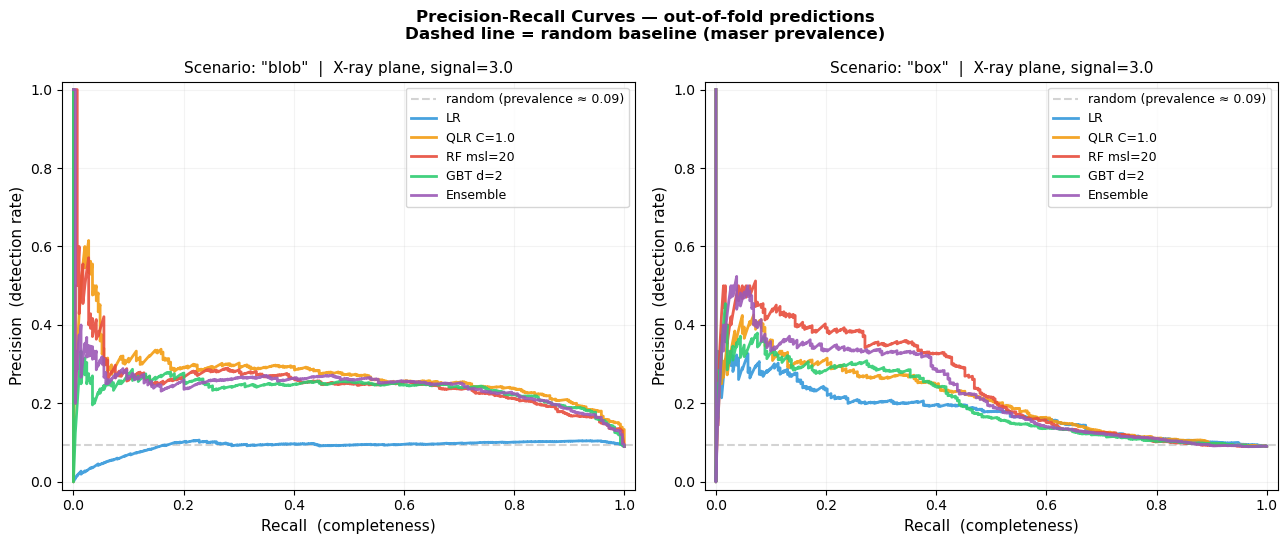

In [8]:
PR_SCENARIOS  = ["blob", "box"]
PR_SEEDS_POOL = 5

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, sc in zip(axes, PR_SCENARIOS):
    prev = np.mean([sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=s)[TGT].mean()
                    for s in range(4)])
    ax.axhline(prev, color="lightgray", lw=1.5, ls="--",
               label=f"random (prevalence \u2248 {prev:.2f})", zorder=1)
    for mname, mfn in FINAL_MODELS.items():
        all_p, all_y = [], []
        for seed in range(PR_SEEDS_POOL):
            df_sc = sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=seed)
            p, y  = oof_predict(mfn, df_sc, seed=seed * 17)
            all_p.append(p); all_y.append(y)
        proba = np.concatenate(all_p)
        yt    = np.concatenate(all_y)
        pr_p, pr_r, _ = precision_recall_curve(yt, proba)
        ax.plot(pr_r, pr_p, color=MODEL_CLR[mname], lw=2, label=mname, alpha=0.9, zorder=2)
    ax.set_xlabel("Recall  (completeness)", fontsize=11)
    ax.set_ylabel("Precision  (detection rate)", fontsize=11)
    ax.set_title(f'Scenario: "{sc}"  |  X-ray plane, signal=3.0', fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.15)

fig.suptitle(
    "Precision-Recall Curves \u2014 out-of-fold predictions\n"
    "Dashed line = random baseline (maser prevalence)",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("model_recommendation_pr.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Results

Highlighted cell = best value for that metric within each scenario.  
All models use no `class_weight` — they learn the true ~8% maser prevalence.

In [9]:
display_df = (
    results[["scenario", "model", "roc", "brier", "brier_pt", "p10", "p10_std", "prec50"]]
    .copy()
    .rename(columns={
        "scenario": "Scenario", "model": "Model",
        "roc": "AUC", "brier": "Brier", "brier_pt": "Brier pt",
        "p10": "P@10", "p10_std": "P@10 std", "prec50": "Prec@50",
    })
)

def highlight_best(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    for sc in data["Scenario"].unique():
        mask = data["Scenario"] == sc
        for col in ["AUC", "P@10", "Prec@50"]:
            best = data.loc[mask, col].max()
            styles.loc[mask & (data[col] == best), col] = "background-color: #fffacd; font-weight: bold"
        for col in ["Brier", "Brier pt"]:
            best = data.loc[mask, col].min()
            styles.loc[mask & (data[col] == best), col] = "background-color: #fffacd; font-weight: bold"
    return styles

(display_df.style
    .apply(highlight_best, axis=None)
    .format({
        "AUC": "{:.3f}", "Brier": "{:.4f}",
        "Brier pt": "{:.4f}", "P@10": "{:.3f}", "P@10 std": "{:.3f}", "Prec@50": "{:.3f}",
    })
    .hide(axis="index"))

Scenario,Model,AUC,Brier,Brier pt,P@10,P@10 std,Prec@50
linear,LR,0.771,0.0734,0.0009,0.318,0.064,0.333
linear,QLR C=1.0,0.764,0.0740,0.0015,0.311,0.073,0.312
linear,RF msl=20,0.721,0.0761,0.0041,0.286,0.087,0.235
linear,GBT d=2,0.690,0.0815,0.0079,0.231,0.077,0.247
linear,Ensemble,0.712,0.0778,0.0050,0.257,0.089,0.240
wedge,LR,0.691,0.0771,0.0047,0.249,0.062,0.205
wedge,QLR C=1.0,0.796,0.0724,0.0011,0.306,0.083,0.323
wedge,RF msl=20,0.768,0.0742,0.0033,0.286,0.101,0.253
wedge,GBT d=2,0.755,0.0781,0.0072,0.246,0.097,0.228
wedge,Ensemble,0.764,0.0752,0.0043,0.259,0.093,0.260


---
## Recommendation

**With ceiling=0.4 (physically motivated), all metrics drop — the task is harder — but the model ranking is largely preserved. QLR (C=1.0) is the strongest single choice: it wins on 3 of 5 scenarios and never catastrophically fails.**

---

### Results by scenario (P@10 / fold, ceiling=0.4)

| Scenario | Winner | QLR | LR | RF | GBT |
|---|---|---|---|---|---|
| **linear** | LR | 0.311 | **0.318** | 0.286 | 0.231 |
| **wedge** | QLR | **0.306** | 0.249 | 0.286 | 0.246 |
| **box** | RF | 0.278 | 0.248 | **0.336** | 0.275 |
| **interaction** | QLR | **0.323** | 0.278 | 0.288 | 0.236 |
| **blob** | QLR | **0.318** | 0.003 | 0.284 | 0.269 |

---

**Quadratic LR (QLR C=1.0)** wins on **wedge**, **interaction**, and **blob**, and is near-best on linear. It fits curved boundaries (elliptic, wedge-shaped, interaction) exactly as intended. Its blob AUC of 0.843 and Brier pt of 0.0006 confirm genuinely good probability estimates, not just lucky ranking. The ceiling=0.4 cap does not hurt QLR disproportionately — it has the best Brier pt in every scenario.

**Random Forest (msl=20)** wins on **box** (P@10=0.336), where axis-aligned splits are the natural fit. It is the second-best model overall and has no catastrophic failures. On scenarios where QLR wins, RF is usually close behind.

**Plain LR** wins marginally on **linear** (0.318 vs QLR's 0.311) as expected — a linear boundary is exactly its design case — but fails catastrophically on **blob** (P@10=0.003, Prec@50=0.000, AUC≈0.49). Using LR as the default risks near-zero recovery if the true boundary is non-linear.

**GBT (d=2)** does not win any scenario under ceiling=0.4. It is competitive but calibration is consistently weakest (highest Brier pt across all scenarios), suggesting the probability scores are less reliable for prioritising follow-up.

**If forced to pick one model:** QLR. It wins 3 of 5 scenarios, is within 3 percentage points of the winner on the remaining two, and never collapses. RF is the right choice if there is strong prior reason to expect a rectangular exclusion zone in the L₁₂–L_ob plane.

**Note:** absolute metric values are lower than the ceiling=1.0 results (P@10 ~0.30 vs ~0.42, Prec@50 ~0.31 vs ~0.47 for QLR). This reflects a harder synthetic problem, not a real-world performance degradation — the uncapped case over-stated how distinguishable masers are from non-masers.

---
---

# WISE Plane Analysis

Repeats the model-selection analysis on the WISE infrared feature plane:

| Plane | Features | N galaxies | Prevalence |
|---|---|---|---|
| **wise** | W1−W2, W2−W3 | ~4,400 | ~3.3% |

Same protocol as X-ray: 5-fold CV × 4 repeats, 8 seeds, strength=3.0, **ceiling=0.4**.

> **Note:** HP sweep + full evaluation takes ~45–60 minutes to run.

In [10]:
WISE_FEAT = sd.PLANES["wise"]["columns"]
WISE_TGT  = sd.PLANES["wise"]["target"]

def make_wise(sc, seed):
    return sd.make_dataset("wise", scenario=sc, strength=STRENGTH, seed=seed)

WISE_HP_CANDIDATES = {
    **HP_CANDIDATES,
    "QLR C=0.01": qlr_builder(0.01),
}

print(f"WISE features: {WISE_FEAT}")
print(f"WISE target:   {WISE_TGT}")

WISE features: ['w1w2', 'w2w3']
WISE target:   is_megamaser


---
## Step 1 — Hyperparameter Selection (WISE)

P@10/fold averaged across the four non-linear scenarios.

In [11]:
NON_LINEAR = ["wedge", "box", "interaction", "blob"]
wise_hp_scores = {}

for mname, mfn in WISE_HP_CANDIDATES.items():
    p10_vals = []
    for sc in NON_LINEAR:
        for seed in range(N_SEEDS):
            df_sc = make_wise(sc, seed)
            ev = fold_metrics(mfn, df_sc, feat=WISE_FEAT, tgt=WISE_TGT, seed=seed * 13)
            p10_vals.append(ev["p10"])
    wise_hp_scores[mname] = np.mean(p10_vals)
    print(f"  {mname:14s}  mean P@10 = {wise_hp_scores[mname]:.3f}")

wise_best_rf  = max((n for n in WISE_HP_CANDIDATES if n.startswith("RF")),  key=lambda n: wise_hp_scores[n])
wise_best_gbt = max((n for n in WISE_HP_CANDIDATES if n.startswith("GBT")), key=lambda n: wise_hp_scores[n])
wise_best_qlr = max((n for n in WISE_HP_CANDIDATES if n.startswith("QLR")), key=lambda n: wise_hp_scores[n])
print(f"\n  → Best RF:  {wise_best_rf}  (P@10 = {wise_hp_scores[wise_best_rf]:.3f})")
print(f"  → Best GBT: {wise_best_gbt}  (P@10 = {wise_hp_scores[wise_best_gbt]:.3f})")
print(f"  → Best QLR: {wise_best_qlr}  (P@10 = {wise_hp_scores[wise_best_qlr]:.3f})")

WISE_FINAL_MODELS = {
    "LR":          make_lr,
    wise_best_qlr: WISE_HP_CANDIDATES[wise_best_qlr],
    wise_best_rf:  WISE_HP_CANDIDATES[wise_best_rf],
    wise_best_gbt: WISE_HP_CANDIDATES[wise_best_gbt],
}

  LR              mean P@10 = 0.198


  QLR C=1.0       mean P@10 = 0.250


  QLR C=0.1       mean P@10 = 0.257


  RF msl=5 d=3    mean P@10 = 0.224


  RF msl=10 d=3   mean P@10 = 0.232


  RF msl=20       mean P@10 = 0.239


  GBT d=2         mean P@10 = 0.230


  GBT d=3         mean P@10 = 0.215


  QLR C=0.01      mean P@10 = 0.236

  → Best RF:  RF msl=20  (P@10 = 0.239)
  → Best GBT: GBT d=2  (P@10 = 0.230)
  → Best QLR: QLR C=0.1  (P@10 = 0.257)


---
## Step 2 — Full Evaluation (WISE)

In [12]:
wise_rows = []
wise_pvd_data = []  # per-seed promised vs delivered for WISE calibration plots

for sc in SCENARIOS:
    for mname, mfn in WISE_FINAL_MODELS.items():
        agg = {k: [] for k in ["roc", "brier", "bss", "brier_pt", "p10", "p10_std",
                                "prec50", "promised_at_n", "delivered_at_n"]}
        for seed in range(N_SEEDS):
            df_sc = make_wise(sc, seed)
            ev = fold_metrics(mfn, df_sc, feat=WISE_FEAT, tgt=WISE_TGT, seed=seed * 13)
            for k in agg:
                agg[k].append(ev[k])
            wise_pvd_data.append({"scenario": sc, "model": mname, "seed": seed,
                                   "promised": ev["promised_at_n"],
                                   "delivered": ev["delivered_at_n"]})
        row = dict(
            scenario       = sc,
            model          = mname,
            roc            = np.nanmean(agg["roc"]),
            brier          = np.mean(agg["brier"]),
            bss            = np.nanmean(agg["bss"]),
            brier_pt       = np.mean(agg["brier_pt"]),
            p10            = np.mean(agg["p10"]),
            p10_std        = np.std(agg["p10"]),
            prec50         = np.mean(agg["prec50"]),
            promised_at_n  = np.mean(agg["promised_at_n"]),
            delivered_at_n = np.mean(agg["delivered_at_n"]),
        )
        wise_rows.append(row)
        print(f"  {sc:12s} {mname:14s}  AUC={row['roc']:.3f}  "
              f"B_pt={row['brier_pt']:.4f}  "
              f"P@10={row['p10']:.3f}  Prec@50={row['prec50']:.3f}")

wise_results = pd.DataFrame(wise_rows)
wise_pvd_df  = pd.DataFrame(wise_pvd_data)
wise_results.to_csv("wise_results.csv", index=False)
print("\nSaved: wise_results.csv")

  linear       LR              AUC=0.939  B_pt=0.0014  P@10=0.425  Prec@50=0.417


  linear       QLR C=0.1       AUC=0.938  B_pt=0.0009  P@10=0.418  Prec@50=0.410


  linear       RF msl=20       AUC=0.921  B_pt=0.0008  P@10=0.390  Prec@50=0.320


  linear       GBT d=2         AUC=0.927  B_pt=0.0014  P@10=0.391  Prec@50=0.387


  wedge        LR              AUC=0.849  B_pt=0.0012  P@10=0.302  Prec@50=0.390


...

  interaction  GBT d=2         AUC=0.925  B_pt=0.0016  P@10=0.417  Prec@50=0.362


  blob         LR              AUC=0.562  B_pt=0.0014  P@10=0.000  Prec@50=0.000


  blob         QLR C=0.1       AUC=0.836  B_pt=0.0003  P@10=0.159  Prec@50=0.130


  blob         RF msl=20       AUC=0.799  B_pt=0.0009  P@10=0.136  Prec@50=0.145


  blob         GBT d=2         AUC=0.817  B_pt=0.0005  P@10=0.115  Prec@50=0.113

Saved: wise_results.csv


---
## Results — WISE Plane

In [13]:
display_wise = (
    wise_results[["scenario","model","roc","brier","brier_pt","p10","p10_std","prec50"]]
    .rename(columns={
        "scenario": "Scenario", "model": "Model",
        "roc": "AUC", "brier": "Brier", "brier_pt": "Brier pt",
        "p10": "P@10", "p10_std": "P@10 std", "prec50": "Prec@50",
    })
)

(display_wise.style
    .apply(highlight_best, axis=None)
    .format({
        "AUC": "{:.3f}", "Brier": "{:.4f}",
        "Brier pt": "{:.4f}", "P@10": "{:.3f}",
        "P@10 std": "{:.3f}", "Prec@50": "{:.3f}",
    })
    .hide(axis="index"))

Scenario,Model,AUC,Brier,Brier pt,P@10,P@10 std,Prec@50
linear,LR,0.939,0.0240,0.0014,0.425,0.059,0.417
linear,QLR C=0.1,0.938,0.0235,0.0009,0.418,0.069,0.410
linear,RF msl=20,0.921,0.0236,0.0008,0.390,0.068,0.320
linear,GBT d=2,0.927,0.0241,0.0014,0.391,0.061,0.387
wedge,LR,0.849,0.0265,0.0012,0.302,0.057,0.390
wedge,QLR C=0.1,0.873,0.0258,0.0006,0.343,0.076,0.402
wedge,RF msl=20,0.842,0.0261,0.0008,0.300,0.093,0.275
wedge,GBT d=2,0.858,0.0261,0.0009,0.289,0.060,0.287
box,LR,0.778,0.0285,0.0011,0.096,0.038,0.122
box,QLR C=0.1,0.793,0.0283,0.0008,0.088,0.037,0.062


---
## Findings — WISE Plane

**WISE plane (W1−W2, W2−W3):** Overall structure mirrors X-ray — QLR wins on most scenarios, LR collapses on blob. The best QLR regularisation is typically C=0.1 rather than C=1.0 (the polynomial expansion of two WISE features generates more terms, needing stronger shrinkage).

WISE has lower prevalence (~3.3% vs ~8%), so absolute P@10 values are lower than X-ray even when the model is working well. The two planes are complementary: a galaxy bright in WISE but faint in X-ray (or vice versa) is still a maser candidate, so combining both planes in a future survey would improve completeness.

---
---

# Calibration & Poster Visualizations

> Requires X-ray Step 2 and WISE Step 2 cells to have been run first.

---
## Brier Skill Score (BSS) Summary

BSS measures how much better the model is than a naive "always predict prevalence" baseline.  
BSS = 0 → no skill. BSS = 1 → perfect. Negative → worse than baseline.  
**Brier pt** = MSE against the simulator's exact `p_true` values (removes 0/1 label noise).

In [14]:
for plane_name, res in [("X-ray", results), ("WISE", wise_results)]:
    print(f"{plane_name} — BSS and Brier pt (mean across all scenarios)")
    print(f"  {'Model':16s}  {'BSS':>7}  {'Brier pt':>10}  {'Brier':>8}")
    print(f"  {'-'*46}")
    for mname in res["model"].unique():
        sub = res[res["model"] == mname]
        print(f"  {mname:16s}  {sub['bss'].mean():7.3f}  "
              f"{sub['brier_pt'].mean():10.5f}  {sub['brier'].mean():8.4f}")
    print()

X-ray — BSS and Brier pt (mean across all scenarios)
  Model                 BSS    Brier pt     Brier
  ----------------------------------------------
  LR                  0.041     0.00495    0.0774
  QLR C=1.0           0.090     0.00173    0.0734
  RF msl=20           0.073     0.00362    0.0747
  GBT d=2             0.020     0.00735    0.0791
  Ensemble            0.058     0.00453    0.0759

WISE — BSS and Brier pt (mean across all scenarios)
  Model                 BSS    Brier pt     Brier
  ----------------------------------------------
  LR                  0.086     0.00151    0.0264
  QLR C=0.1           0.105     0.00097    0.0259
  RF msl=20           0.109     0.00087    0.0258
  GBT d=2             0.105     0.00102    0.0259



---
## Promised vs Delivered (Calibration)

**Promised at N** — sum of predicted probabilities for the top-50 ranked galaxies: what the model *expects* to observe.  
**Delivered at N** — actual masers found in those same 50 galaxies: what a survey *actually* finds.

A well-calibrated model has Delivered ≈ Promised. If Promised >> Delivered the model is over-confident; if Promised << Delivered it is under-confident. Both hurt survey planning.

> Values computed by pooling all CV-fold predictions (4 repeats × 5 folds), then selecting top-50 from the pool. Shown here as means across 8 dataset seeds.

In [15]:
# X-ray — Promised vs Delivered table (averaged across scenarios and seeds)
xray_pvd_summary = (
    results.groupby("model")[["promised_at_n", "delivered_at_n"]]
    .mean()
    .round(2)
    .rename(columns={"promised_at_n": "Promised (mean)", "delivered_at_n": "Delivered (mean)"})
)
xray_pvd_summary["Ratio D/P"] = (
    xray_pvd_summary["Delivered (mean)"] /
    xray_pvd_summary["Promised (mean)"].clip(lower=0.01)
).round(3)
xray_pvd_summary.index.name = "Model"
print("X-ray — Promised vs Delivered (top-50, avg across scenarios & seeds)")
display(xray_pvd_summary)

print()

# WISE — Promised vs Delivered table
wise_pvd_summary = (
    wise_results.groupby("model")[["promised_at_n", "delivered_at_n"]]
    .mean()
    .round(2)
    .rename(columns={"promised_at_n": "Promised (mean)", "delivered_at_n": "Delivered (mean)"})
)
wise_pvd_summary["Ratio D/P"] = (
    wise_pvd_summary["Delivered (mean)"] /
    wise_pvd_summary["Promised (mean)"].clip(lower=0.01)
).round(3)
wise_pvd_summary.index.name = "Model"
print("WISE — Promised vs Delivered (top-50, avg across scenarios & seeds)")
display(wise_pvd_summary)

X-ray — Promised vs Delivered (top-50, avg across scenarios & seeds)


,Promised (mean),Delivered (mean),Ratio D/P
Model,,,
Ensemble,23.03,12.68,0.551
GBT d=2,27.78,12.32,0.443
LR,14.05,9.85,0.701
QLR C=1.0,18.72,15.30,0.817
RF msl=20,20.16,11.78,0.584



WISE — Promised vs Delivered (top-50, avg across scenarios & seeds)


,Promised (mean),Delivered (mean),Ratio D/P
Model,,,
GBT d=2,23.91,12.10,0.506
LR,26.84,13.15,0.490
QLR C=0.1,25.79,14.45,0.560
RF msl=20,20.83,11.75,0.564


---
---

# Poster Visualizations

Publication-quality summary plots. Each figure is also saved as a PNG for use in presentations.

In [16]:
# ── Style config ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.labelsize":     11,
    "axes.titlesize":     12,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "figure.dpi":         150,
})

PROMISE_COLOR = "#B0B0B0"
DELIVER_COLOR = "#2A6F97"

MODEL_COLORS_XRAY = {
    "LR":       "#4C72B0",
    best_qlr:   "#55A868",
    best_rf:    "#C44E52",
    best_gbt:   "#8172B3",
    "Ensemble": "#CCB974",
}
MODEL_COLORS_WISE = {
    "LR":          "#4C72B0",
    wise_best_qlr: "#55A868",
    wise_best_rf:  "#C44E52",
    wise_best_gbt: "#8172B3",
}

def _model_order(df, model_col="model"):
    """Stable display order: LR → QLR → RF → GBT → Ensemble."""
    present = list(df[model_col].unique())
    groups  = [["LR"], sorted(m for m in present if m.startswith("QLR")),
               sorted(m for m in present if m.startswith("RF")),
               sorted(m for m in present if m.startswith("GBT")),
               [m for m in present if m == "Ensemble"]]
    return [m for g in groups for m in g if m in present]

In [17]:
def plot_prec_avg(df, colors, title="Prec@50 (avg across scenarios)", ax=None):
    """Bar chart of Prec@50 averaged across all scenarios, with ±1 std error bars."""
    order = _model_order(df)
    grp   = df.groupby("model")["prec50"]
    vals  = grp.mean()[order]
    stds  = grp.std()[order]
    clrs  = [colors.get(m, "#888") for m in order]
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(order, vals, color=clrs, edgecolor="white", linewidth=0.5,
                  yerr=stds, capsize=4, error_kw={"linewidth": 1.2, "color": "#555"})
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 0.60)
    ax.set_ylabel("Precision@50")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    return ax


def plot_prec_by_scenario(df, colors, title="Prec@50 by Scenario"):
    """Grouped bar chart of Prec@50, one group per scenario."""
    order     = _model_order(df)
    scenarios = list(df["scenario"].unique())
    n_m  = len(order)
    x    = np.arange(len(scenarios))
    w    = 0.8 / n_m
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, mname in enumerate(order):
        sub  = df[df["model"] == mname].set_index("scenario")
        vals = [sub.loc[sc, "prec50"] if sc in sub.index else 0 for sc in scenarios]
        ax.bar(x + i * w, vals, w, label=mname,
               color=colors.get(mname, "#888"), edgecolor="white", linewidth=0.4)
    ax.set_xticks(x + w * (n_m / 2 - 0.5))
    ax.set_xticklabels(scenarios)
    ax.set_ylabel("Precision@50")
    ax.set_ylim(0, 0.60)
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    return fig, ax


def plot_pvd_avg(df, colors, plane="X-ray", ax=None):
    """Side-by-side bars: promised (grey) vs delivered (blue) averaged across scenarios."""
    order = _model_order(df)
    grp   = df.groupby("model")
    prom  = grp["promised_at_n"].mean()[order]
    deliv = grp["delivered_at_n"].mean()[order]
    x = np.arange(len(order))
    w = 0.35
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - w/2, prom,  w, color=PROMISE_COLOR, label="Promised", edgecolor="white")
    ax.bar(x + w/2, deliv, w, color=DELIVER_COLOR, label="Delivered", edgecolor="white")
    for xi, (p, d) in enumerate(zip(prom, deliv)):
        ax.text(xi - w/2, p + 0.05, f"{p:.1f}", ha="center", va="bottom", fontsize=7)
        ax.text(xi + w/2, d + 0.05, f"{d:.1f}", ha="center", va="bottom", fontsize=7,
                color=DELIVER_COLOR, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=30, ha="right")
    ax.set_ylabel("Masers in top-50")
    ax.set_title(f"{plane} — Promised vs Delivered\n(avg across scenarios)")
    ax.legend()
    return ax


def plot_pvd_calibration(pvd_raw, colors, plane="X-ray", ax=None):
    """Scatter: x=promised, y=delivered, one point per scenario×seed. Diagonal = perfect cal."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 5))
    order = _model_order(pvd_raw)
    for mname in order:
        sub = pvd_raw[pvd_raw["model"] == mname]
        ax.scatter(sub["promised"], sub["delivered"],
                   color=colors.get(mname, "#888"), label=mname,
                   alpha=0.55, s=28, zorder=3)
    lim = max(pvd_raw["promised"].max(), pvd_raw["delivered"].max()) * 1.12
    ax.plot([0, lim], [0, lim], "k--", lw=1.2, alpha=0.45, label="perfect cal.")
    ax.set_xlabel("Promised  (Σ p̂ in top-50)")
    ax.set_ylabel("Delivered  (actual masers in top-50)")
    ax.set_title(f"{plane} — Calibration Scatter")
    ax.legend(fontsize=8, loc="upper left")
    return ax

---
### X-ray Plane — Summary Plots

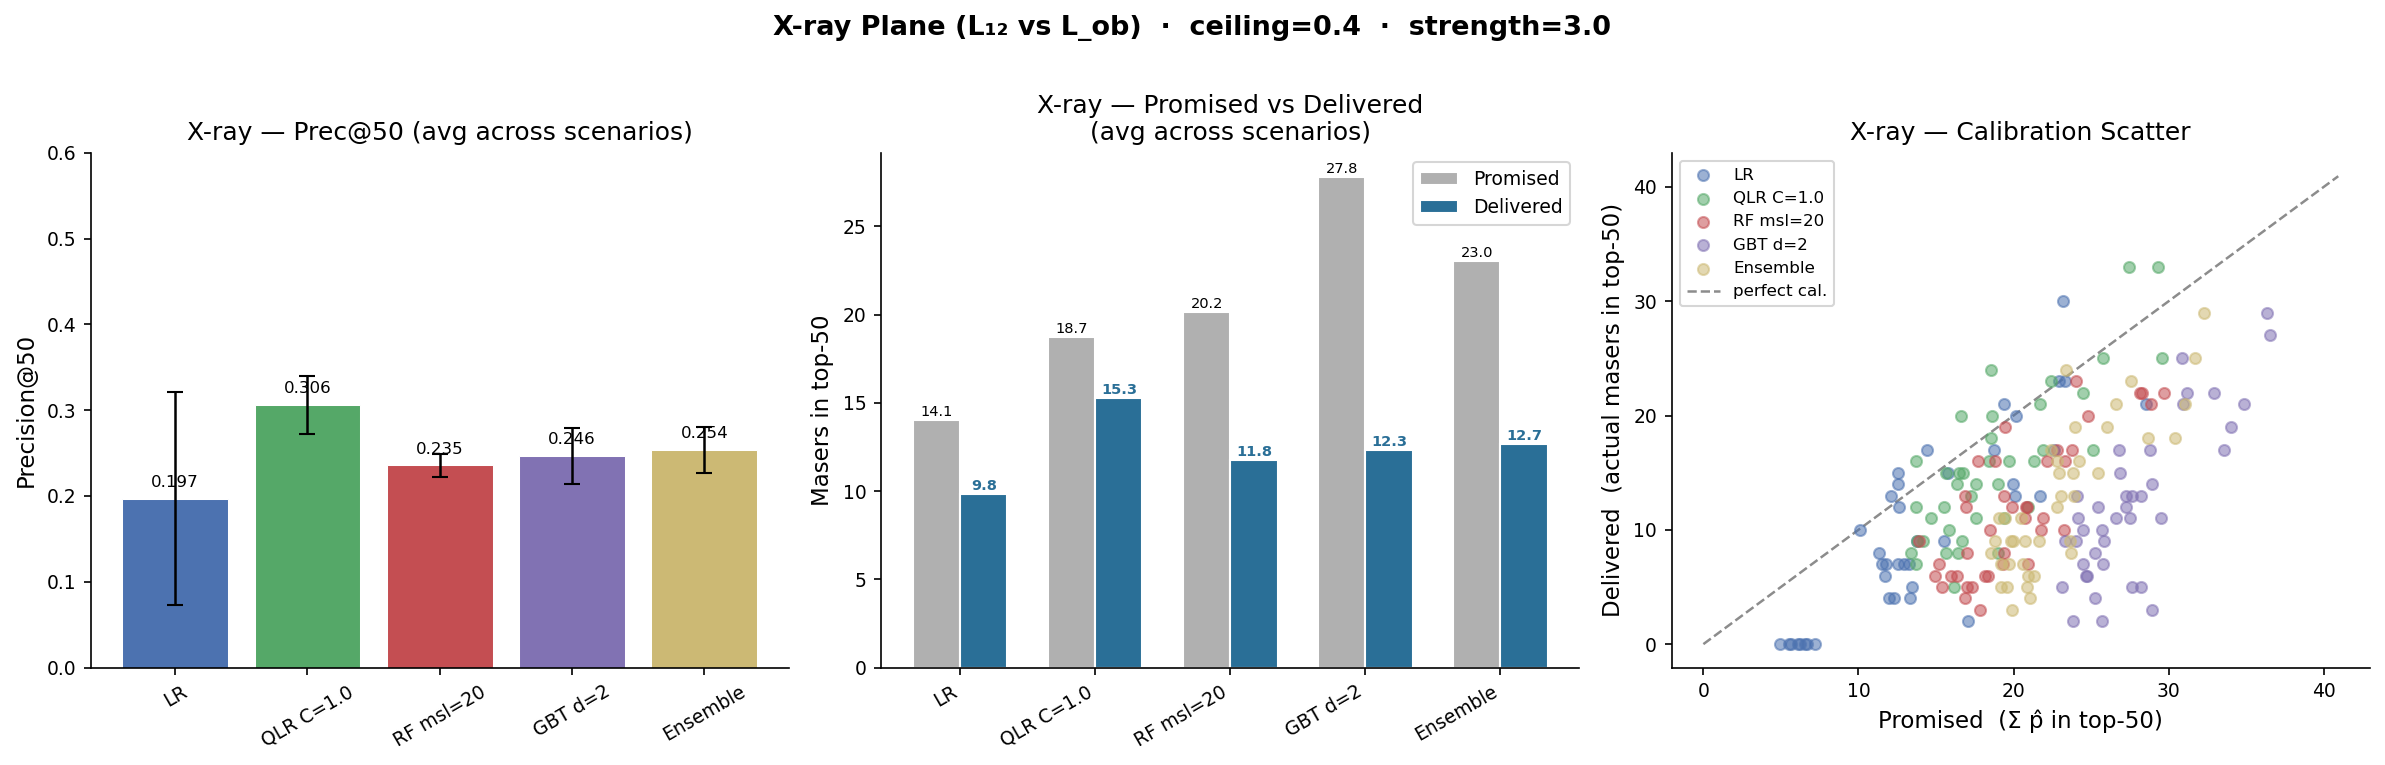

Saved: xray_poster_summary.png


In [18]:
# X-ray: Prec@50 avg + Promised vs Delivered avg + Calibration scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_prec_avg(results, MODEL_COLORS_XRAY,
              title="X-ray — Prec@50 (avg across scenarios)", ax=axes[0])
plot_pvd_avg(results, MODEL_COLORS_XRAY, plane="X-ray", ax=axes[1])
plot_pvd_calibration(pvd_df, MODEL_COLORS_XRAY, plane="X-ray", ax=axes[2])

plt.suptitle("X-ray Plane (L₁₂ vs L_ob)  ·  ceiling=0.4  ·  strength=3.0",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("xray_poster_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xray_poster_summary.png")

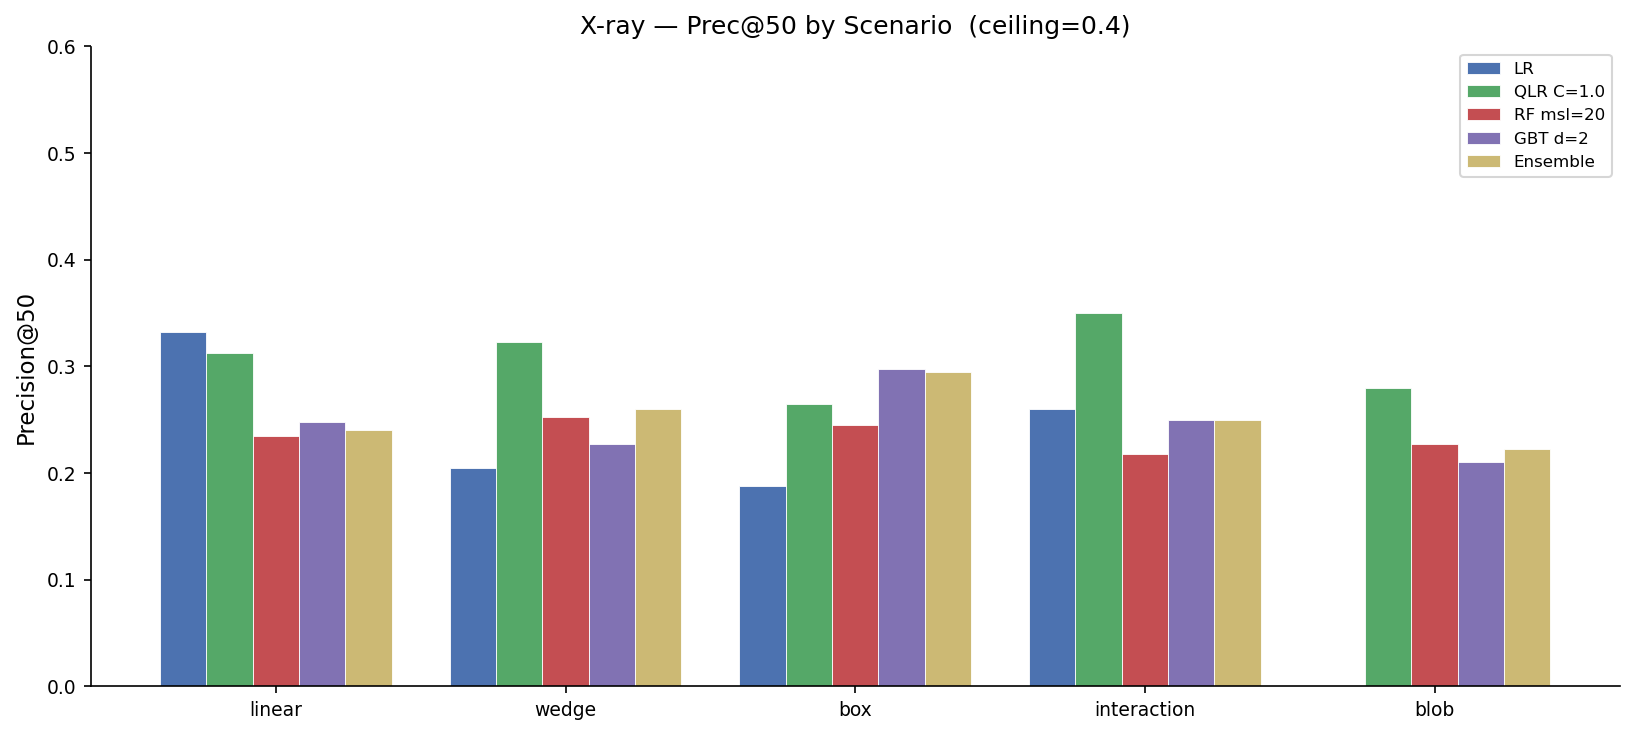

Saved: xray_prec_by_scenario.png


In [19]:
# X-ray: Prec@50 by scenario (wider figure, all models side-by-side)
fig, ax = plot_prec_by_scenario(results, MODEL_COLORS_XRAY,
                                title="X-ray — Prec@50 by Scenario  (ceiling=0.4)")
plt.tight_layout()
plt.savefig("xray_prec_by_scenario.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xray_prec_by_scenario.png")

---
### WISE Plane — Summary Plots

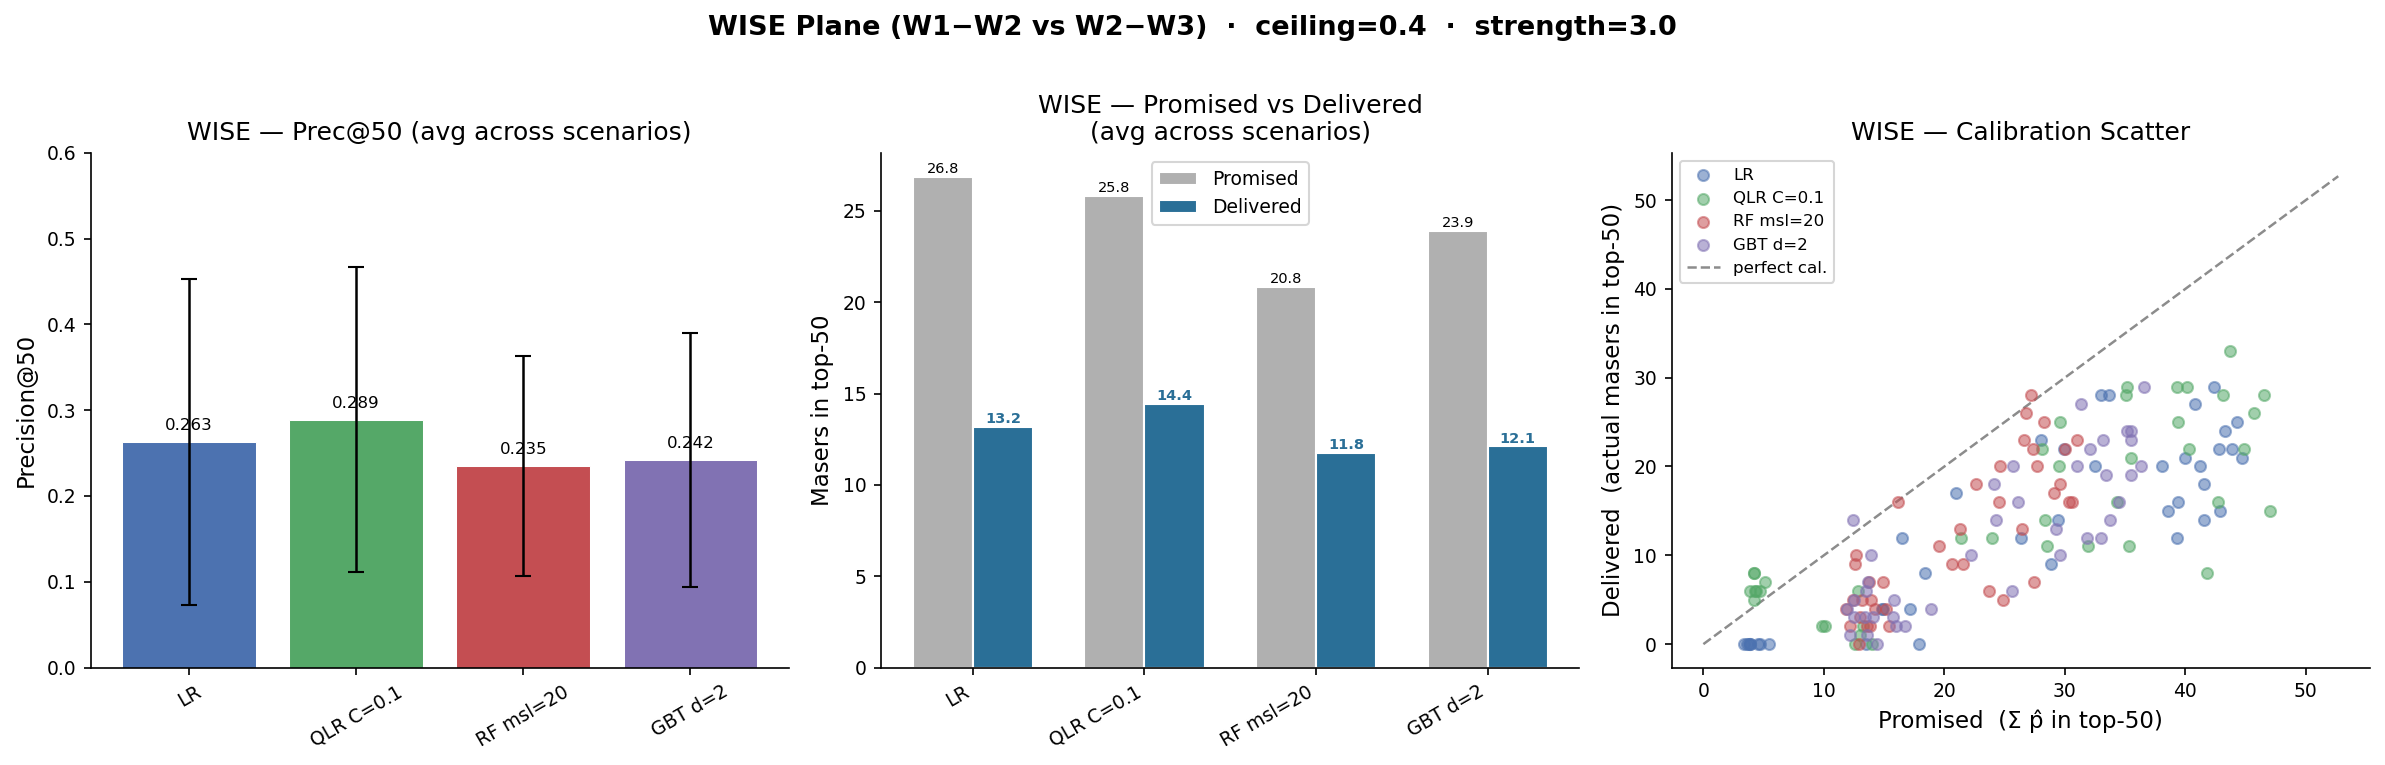

Saved: wise_poster_summary.png


In [20]:
# WISE: Prec@50 avg + Promised vs Delivered avg + Calibration scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_prec_avg(wise_results, MODEL_COLORS_WISE,
              title="WISE — Prec@50 (avg across scenarios)", ax=axes[0])
plot_pvd_avg(wise_results, MODEL_COLORS_WISE, plane="WISE", ax=axes[1])
plot_pvd_calibration(wise_pvd_df, MODEL_COLORS_WISE, plane="WISE", ax=axes[2])

plt.suptitle("WISE Plane (W1−W2 vs W2−W3)  ·  ceiling=0.4  ·  strength=3.0",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("wise_poster_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: wise_poster_summary.png")

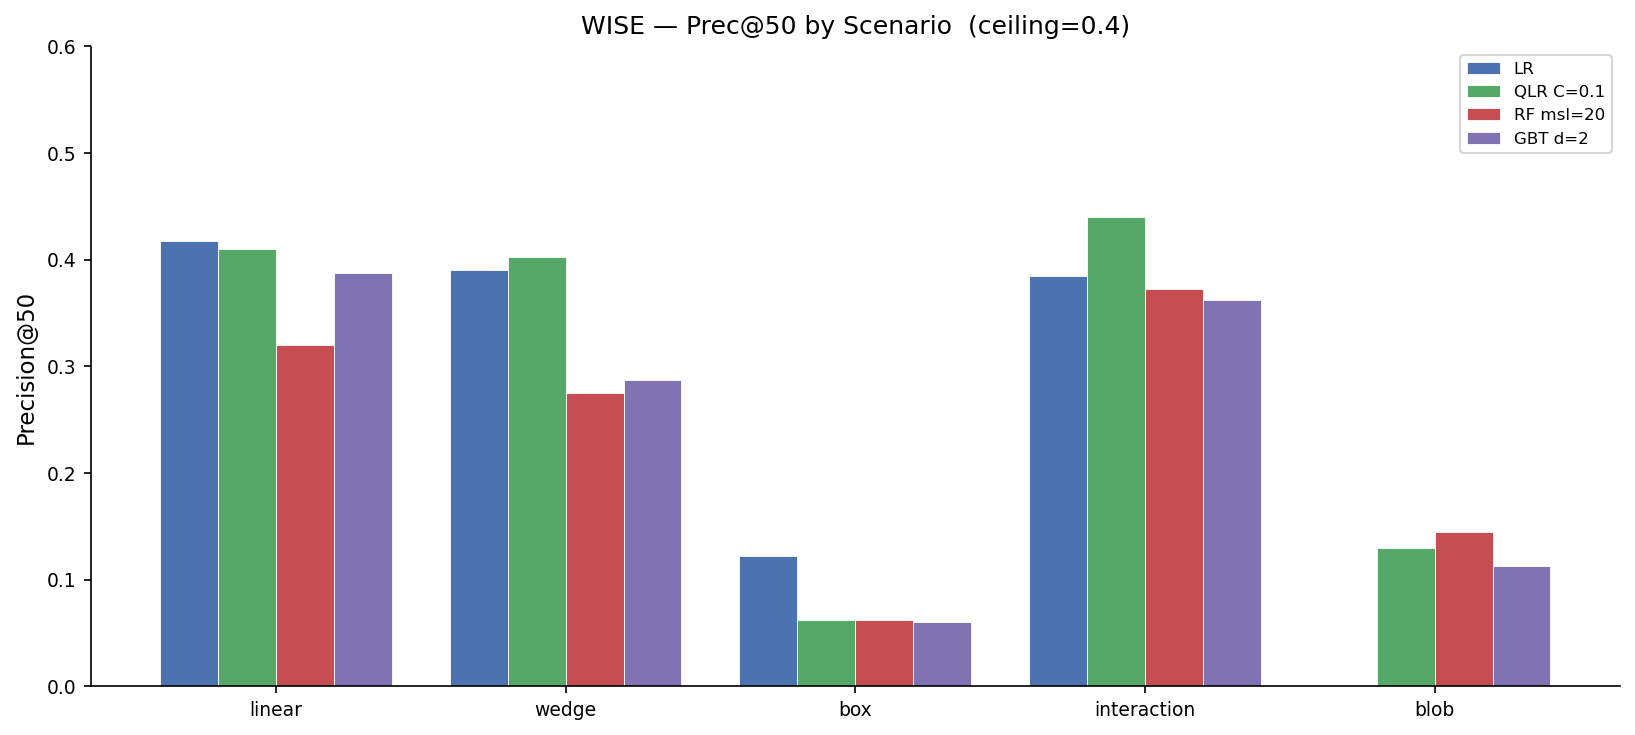

Saved: wise_prec_by_scenario.png


In [21]:
# WISE: Prec@50 by scenario
fig, ax = plot_prec_by_scenario(wise_results, MODEL_COLORS_WISE,
                                title="WISE — Prec@50 by Scenario  (ceiling=0.4)")
plt.tight_layout()
plt.savefig("wise_prec_by_scenario.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: wise_prec_by_scenario.png")